# SARSA and Q-Learning on Taxi_v3

SARSA learns Q(s,a) — action values — using the **actual next action taken**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ R + \gamma \; Q(s', \underbrace{a'}_{\text{action actually taken}}) - Q(s,a) \Big]$$

The name comes from the quintuple: **(S, A, R, S', A')**  
On-policy: the policy being improved is the same one being followed.

Q-Learning uses the **greedy next action** in its update — regardless of what the agent actually does:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ R + \gamma \; \underbrace{\max_{a'} Q(s', a')}_{\text{greedy, not taken}} - Q(s,a) \Big]$$

In [1]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys; subprocess.check_call([sys.executable,'-m','pip','install','gymnasium','-q']); import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

env = gym.make('Taxi-v3')
n_s = env.observation_space.n; n_a = env.action_space.n
print(f"Taxi-v3: {n_s} states, {n_a} actions")

Taxi-v3: 500 states, 6 actions


## 1. SARSA Implementation

In [2]:
def sarsa(env, n_episodes=10_000, alpha=0.1, gamma=0.99,
          eps_start=1.0, eps_end=0.01, eps_decay=0.999):
    Q = np.zeros((n_s, n_a))
    eps = eps_start
    returns_per_ep = []
    steps_per_ep = []

    def eps_greedy(s):
        if np.random.rand() < eps: return env.action_space.sample()
        return np.argmax(Q[s])

    for ep in range(n_episodes):
        s, _ = env.reset()
        a = eps_greedy(s)
        ep_return = 0.0
        steps = 0
        done = False

        while not done:
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            na = eps_greedy(ns)

            # SARSA update — uses next action a' that was CHOSEN (on-policy)
            Q[s,a] += alpha * (r + gamma * Q[ns,na] * (not done) - Q[s,a])

            s, a = ns, na
            ep_return += r
            steps += 1

        eps = max(eps_end, eps * eps_decay)
        returns_per_ep.append(ep_return)
        steps_per_ep.append(steps)

    return Q, returns_per_ep, steps_per_ep

print("Training SARSA on Taxi-v3...")
Q_sarsa, returns_sarsa, steps_sarsa = sarsa(env, n_episodes=15_000)
print(f"Done. Final ε ≈ 0.01")

Training SARSA on Taxi-v3...
Done. Final ε ≈ 0.01


## 2. Q-Learning Implementation

In [5]:
def q_learning(env, n_episodes=15_000, alpha=0.1, gamma=0.99,
               eps_start=1.0, eps_end=0.01, eps_decay=0.999):
    Q = np.zeros((n_s, n_a))
    eps = eps_start
    returns_per_ep = []
    steps_per_ep = []

    for ep in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0.0; steps = 0; done = False
        while not done:
            # Choose action (ε-greedy behaviour policy)
            a = env.action_space.sample() if np.random.rand()<eps else np.argmax(Q[s])
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc

            # Q-Learning update — uses max Q[ns], NOT the action taken
            Q[s,a] += alpha * (r + gamma * np.max(Q[ns]) * (not done) - Q[s,a])

            s = ns; ep_return += r; steps += 1

        eps = max(eps_end, eps * eps_decay)
        returns_per_ep.append(ep_return)
        steps_per_ep.append(steps)

    return Q, returns_per_ep, steps_per_ep

print("Training Q-Learning on Taxi-v3...")
Q_ql, returns_ql, steps_ql = q_learning(env)
print("Done.")

Training Q-Learning on Taxi-v3...
Done.


## 3. One-line difference from SARSA
- SARSA: `Q[s,a] += alpha * (r + gamma * Q[ns, next_action_taken] - Q[s,a])`
- Q-Learning: `Q[s,a] += alpha * (r + gamma * max(Q[ns]) - Q[s,a])`

## 4. SARSA vs QLearning plot

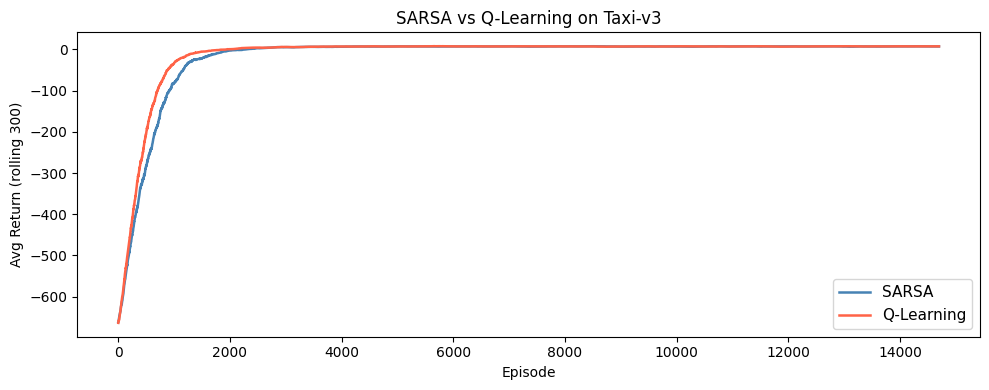

In [7]:
def sarsa(env, n_episodes=15_000, alpha=0.1, gamma=0.99, eps_start=1.0, eps_end=0.01, eps_decay=0.999):
    Q = np.zeros((n_s, n_a)); eps = eps_start
    returns_per_ep = []
    for ep in range(n_episodes):
        s,_ = env.reset()
        a = env.action_space.sample() if np.random.rand()<eps else np.argmax(Q[s])
        ep_r = 0; done = False
        while not done:
            ns,r,term,trunc,_ = env.step(a)
            done=term or trunc
            na = env.action_space.sample() if np.random.rand()<eps else np.argmax(Q[ns])
            Q[s,a] += alpha*(r + gamma*Q[ns,na]*(not done) - Q[s,a])
            s,a = ns,na; ep_r+=r
        eps=max(eps_end, eps*eps_decay)
        returns_per_ep.append(ep_r)
    return Q, returns_per_ep

np.random.seed(42)
Q_s, ret_s = sarsa(env)
np.random.seed(42)
Q_q, ret_q = q_learning(env)[:2]

window = 300
fig, ax = plt.subplots(figsize=(10, 4))
for ret, label, color in [(ret_s,'SARSA','steelblue'), (ret_q,'Q-Learning','tomato')]:
    rolling = np.convolve(ret, np.ones(window)/window, mode='valid')
    ax.plot(rolling, color=color, linewidth=1.8, label=label)
ax.set_xlabel('Episode'); ax.set_ylabel(f'Avg Return (rolling {window})')
ax.set_title('SARSA vs Q-Learning on Taxi-v3')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

## 5. Q-Table Heatmap